In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("olist_orders_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")
df_reviews = pd.read_csv("olist_order_reviews_dataset.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(99441, 8)
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [3]:
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Target 1: delivery delay in days (positive = late)
df['delivery_delay'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df = df.dropna(subset=['delivery_delay'])
print(df['delivery_delay'].describe())

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64


In [7]:
merged = df.merge(
    df_items[['order_id', 'price', 'freight_value', 'product_id']],
    on='order_id', how='left'
)

features = ['price', 'freight_value']
X = merged[features].fillna(0)
y = merged['delivery_delay'].fillna(0)

print(f"Dataset size: {X.shape}")
print(X.head())

Dataset size: (110196, 2)
    price  freight_value
0   29.99           8.72
1  118.70          22.76
2  159.90          19.22
3   45.00          27.20
4   19.90           8.72


RMSE: 10.18 days


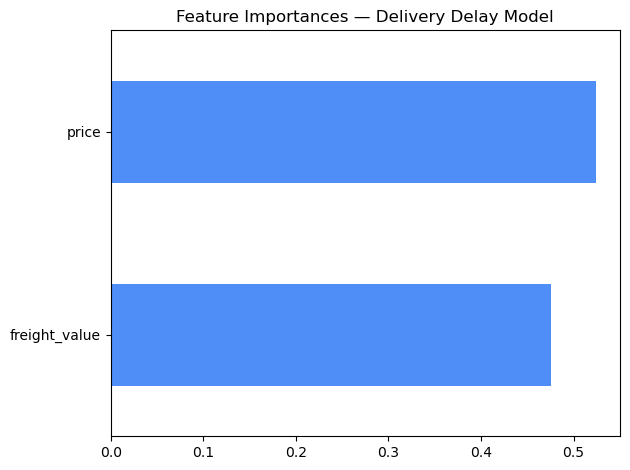

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f} days")

# Feature importance plot
importances = pd.Series(reg.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='#4F8EF7',
    title='Feature Importances — Delivery Delay Model')
plt.tight_layout()
plt.savefig('reg_feature_importance.png', dpi=150)
plt.show()

In [9]:
merged2 = merged.merge(
    df_reviews[['order_id', 'review_score']], on='order_id', how='left'
)
merged2['is_bad_review'] = (merged2['review_score'] == 1).astype(int)

print(merged2['is_bad_review'].value_counts())
print(merged2['is_bad_review'].value_counts(normalize=True))
# Expect ~10–15% bad reviews — this is imbalanced, which is intentional

X2 = merged2[features + ['delivery_delay']].fillna(0)
y2 = merged2['is_bad_review'].fillna(0).astype(int)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # critical for imbalanced classes
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train2, y_train2)

0    98261
1    12578
Name: is_bad_review, dtype: int64
0    0.88652
1    0.11348
Name: is_bad_review, dtype: float64


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [10]:
y_pred2 = clf.predict(X_test2)

print(f"Accuracy: {accuracy_score(y_test2, y_pred2):.3f}")

cm = confusion_matrix(y_test2, y_pred2)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_test2, y_pred2,
    target_names=['Good Review', 'Bad Review']))

Accuracy: 0.905

Confusion Matrix:
 [[18859   793]
 [ 1309  1207]]

Classification Report:
              precision    recall  f1-score   support

 Good Review       0.94      0.96      0.95     19652
  Bad Review       0.60      0.48      0.53      2516

    accuracy                           0.91     22168
   macro avg       0.77      0.72      0.74     22168
weighted avg       0.90      0.91      0.90     22168

